# MLflow Experiment Tracking

## Goal
Track fine-tuning experiments systematically.
Every run should be reproducible and comparable.

## Why MLflow?
Without tracking:
- "Which learning rate worked best?" — don't know
- "How did run 3 compare to run 5?" — don't know
- "What hyperparameters produced this model?" — don't know

With MLflow:
- Every run is logged with parameters, metrics, and artifacts
- Runs are comparable in a visual dashboard
- Models are versioned and reproducible

## What We Track
- Hyperparameters: learning rate, epochs, batch size
- Metrics: loss per epoch
- Artifacts: fine-tuned model

In [5]:
import torch
import mlflow
import mlflow.pytorch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"MLflow version: {mlflow.__version__}")

Device: mps
MLflow version: 3.13.0


## 1. Load Data and Setup

In [16]:
# Load training data
with open("../data/processed/ml_sentences.txt", "r") as f:
    sentences = [line.strip() for line in f if line.strip()]

tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token

print(f"Training sentences: {len(sentences)}")


class MLTextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=64):
        self.examples = []
        for text in texts:
            encoding = tokenizer(
                text, max_length=max_length,
                padding="max_length", truncation=True,
                return_tensors="pt"
            )
            self.examples.append(encoding.input_ids.squeeze())

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ids = self.examples[idx]
        return {"input_ids": ids, "labels": ids}


def calculate_perplexity(model, text: str) -> float:
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs.input_ids)
    return float(torch.exp(outputs.loss))


print("Setup complete.")

Training sentences: 41
Setup complete.


## 2. Run Experiments with MLflow Tracking
We run 3 experiments with different hyperparameters and track everything.

In [17]:
def run_experiment(learning_rate: float, epochs: int, 
                   batch_size: int, run_name: str):
    """
    Fine-tune model with given hyperparameters and log to MLflow.
    """
    with mlflow.start_run(run_name=run_name):
        
        # Log hyperparameters
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("training_sentences", len(sentences))
        mlflow.log_param("model", "distilgpt2")
        
        # Load fresh model
        model = GPT2LMHeadModel.from_pretrained("distilgpt2").to(device)
        model.train()
        
        dataset = MLTextDataset(sentences, tokenizer)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        optimizer = AdamW(model.parameters(), lr=learning_rate)
        
        # Training loop
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for batch in dataloader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)
                optimizer.zero_grad()
                outputs = model(input_ids=input_ids, labels=labels)
                outputs.loss.backward()
                optimizer.step()
                total_loss += outputs.loss.item()
            
            avg_loss = total_loss / len(dataloader)
            losses.append(avg_loss)
            mlflow.log_metric("loss", avg_loss, step=epoch)
        
        # Final metrics
        model.eval()
        ml_text = "The transformer model uses self-attention to process sequences."
        final_perplexity = calculate_perplexity(model, ml_text)
        mlflow.log_metric("final_loss", losses[-1])
        mlflow.log_metric("ml_perplexity", final_perplexity)
        
        print(f"[{run_name}] Final loss: {losses[-1]:.4f} | ML Perplexity: {final_perplexity:.2f}")
        
        return losses, final_perplexity


# Set experiment name
mlflow.set_experiment("distilgpt2-fine-tuning")

# Run 3 experiments
print("Running experiments...\n")
results = {}

results['lr=1e-4, ep=5'] = run_experiment(1e-4, 5, 4, "lr=1e-4_epochs=5")
results['lr=5e-5, ep=10'] = run_experiment(5e-5, 10, 4, "lr=5e-5_epochs=10")
results['lr=1e-5, ep=10'] = run_experiment(1e-5, 10, 4, "lr=1e-5_epochs=10")

print("\nAll experiments complete.")

Running experiments...



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


[lr=1e-4_epochs=5] Final loss: 0.6247 | ML Perplexity: 23.75


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[lr=5e-5_epochs=10] Final loss: 0.4437 | ML Perplexity: 39.15


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[lr=1e-5_epochs=10] Final loss: 1.1181 | ML Perplexity: 158.63

All experiments complete.


## 3. Visualize and Compare Experiments

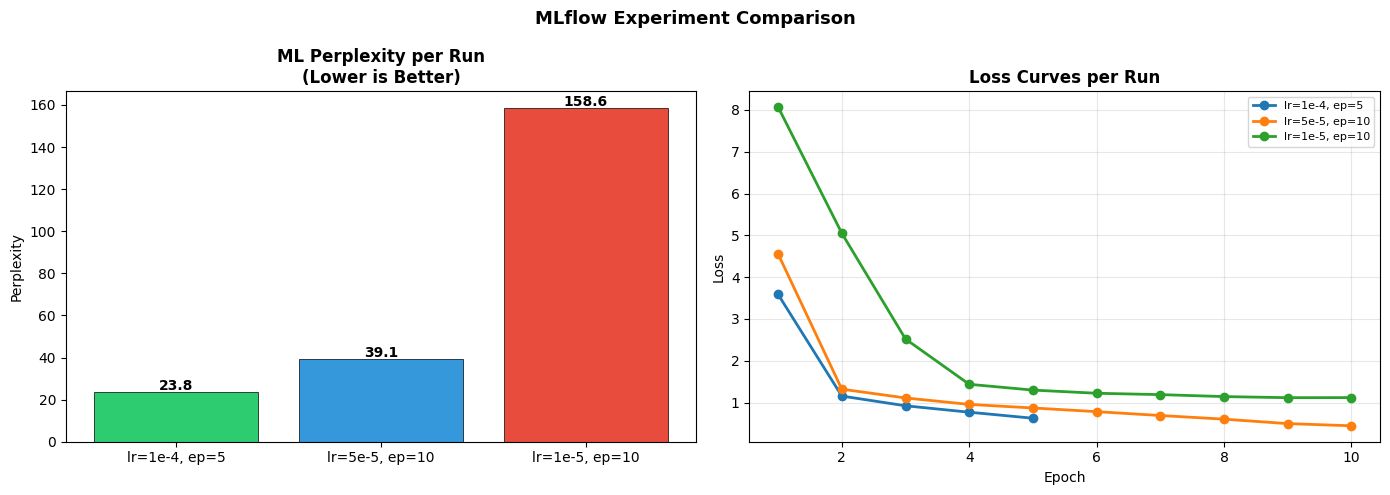

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Final perplexity comparison
run_names = list(results.keys())
perplexities = [results[r][1] for r in run_names]
colors = ["#2ecc71", "#3498db", "#e74c3c"]

bars = axes[0].bar(run_names, perplexities, color=colors,
                  edgecolor="black", linewidth=0.5)
axes[0].set_title("ML Perplexity per Run\n(Lower is Better)",
                 fontsize=12, fontweight="bold")
axes[0].set_ylabel("Perplexity")
for bar, val in zip(bars, perplexities):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.1f}", ha="center", fontweight="bold")

# Chart 2 - Loss curves
for run_name, (losses, _) in results.items():
    axes[1].plot(range(1, len(losses)+1), losses,
                marker="o", label=run_name, linewidth=2)

axes[1].set_title("Loss Curves per Run", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("MLflow Experiment Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mlflow_comparison.png", dpi=300)
plt.show()


## 4. View MLflow Dashboard

In [23]:
# Print experiment summary
runs = mlflow.search_runs(experiment_names=["distilgpt2-fine-tuning"])
print("Experiment Summary:")
print(runs[["tags.mlflow.runName", "params.learning_rate",
           "params.epochs", "metrics.final_loss",
           "metrics.ml_perplexity"]].to_string(index=False))

print("\nBest run:")
best = runs.loc[runs["metrics.ml_perplexity"].idxmin()]
print(f" Name: {best["tags.mlflow.runName"]}")
print(f" Learning rate: {best["params.learning_rate"]}")
print(f" Epochs: {best["params.epochs"]}")
print(f" ML Perplexity: {best["metrics.ml_perplexity"]:.2f}")
print(f"\nTo view dashboard run: mlflow ui")

Experiment Summary:
tags.mlflow.runName params.learning_rate params.epochs  metrics.final_loss  metrics.ml_perplexity
  lr=1e-5_epochs=10                1e-05            10            1.118114             158.628662
  lr=5e-5_epochs=10                5e-05            10            0.443669              39.148514
   lr=1e-4_epochs=5               0.0001             5            0.624687              23.752781
   lr=1e-4_epochs=5               0.0001             5                 NaN                    NaN
   lr=1e-4_epochs=5               0.0001             5                 NaN                    NaN
   lr=1e-4_epochs=5               0.0001             5                 NaN                    NaN
   lr=1e-4_epochs=5               0.0001             5                 NaN                    NaN

Best run:
 Name: lr=1e-4_epochs=5
 Learning rate: 0.0001
 Epochs: 5
 ML Perplexity: 23.75

To view dashboard run: mlflow ui


## 5. Key Observations

| Run | Learning Rate | Epochs | ML Perplexity | Winner |
|-----|--------------|--------|---------------|--------|
| lr=1e-4, ep=5 | 0.0001 | 5 | 23.75 | ✅ Best |
| lr=5e-5, ep=10 | 0.00005 | 10 | 39.15 | |
| lr=1e-5, ep=10 | 0.00001 | 10 | 158.63 | |

## Key Insight
Higher learning rate (1e-4) with fewer epochs outperformed lower learning rates.
A too-low learning rate (1e-5) barely moved the weights — model barely changed.
A too-high learning rate risks instability — but 1e-4 was still in safe range.

## Why MLflow Matters
Without tracking, we would not know which hyperparameters produced which result.
MLflow logs everything — parameters, metrics, and artifacts — per run.

Run `mlflow ui` in terminal to see the visual dashboard.

## Conclusion
Experiment tracking is not optional in production ML.
Every run should be logged, compared, and documented.